In [2]:
# Import useful packages for galactic unresolved stellar population synthesis (SPS) modeling
import numpy as np
import matplotlib.pyplot as plt
import fsps
import pandas as pd

# Needed to export the directory so fsps knows where to look. I thought I only
# had to do this once when I intalled, but I need to do it every time. Gemini
# had me put it in my conda env config file because I didn't want to clutter my
# bashrc. First I activated the ay_250 env, then I ran conda env config vars set SPS_HOME="/path/"
# and then I had to reactivate the env but now it works
# export SPS_HOME="/mnt/c/Users/noahs/Desktop/Berkeley/Year 1/Semester 2/Stellar Pops/fsps"

In [4]:
# Load the galaxy spectra
galaxy_filename = "mystery_galaxy_sed.tsv"
galaxy_data = pd.read_csv(galaxy_filename, sep="\t")

In [23]:
# Put wavelength in the pandas dataframe, convert from frequency
c_m_s = 299792458
galaxy_data["Wavelength (m)"] = c_m_s / galaxy_data["Frequency (Hz)"]
galaxy_data["Wavelength (Angstrom)"] = galaxy_data["Wavelength (m)"] * 1e10
galaxy_data["Flux Density (Jy)"] = galaxy_data["Flux Density"]
galaxy_data["Flux Density (erg)"] = galaxy_data["Flux Density (Jy)"] * 1e-23
galaxy_data["FD Unc High (erg)"] = galaxy_data["FD Unc High"] * 1e-23
galaxy_data["FD Unc Low (erg)"] = galaxy_data["FD Unc Low"] * 1e-23

In [13]:
galaxy_data.head(5)

,Bandpass,Magnitude,Unc High,Unc Low,Unit,Frequency (Hz),Flux Density,FD Unc High,FD Unc Low,Flux,F Unc High,F Unc Low,Telescope,wavelength_meter,wavelength,Wavelength (m),Wavelength (Angstrom)
0,FUV (GALEX) AB,13.83,0.01,0.01,mag,1.960000e+15,0.010670,0.000098,0.000098,2.091320e+13,1.925504e+11,1.925504e+11,GALEX,1.529553e-07,1529.553354,1.529553e-07,1529.553354
1,NUV (GALEX) AB,14.12,0.01,0.01,mag,1.320000e+15,0.008166,0.000075,0.000075,1.077912e+13,9.927720e+10,9.927720e+10,GALEX,2.271155e-07,2271.155071,2.271155e-07,2271.155071
2,u (SDSS) AB,13.37,0.05,0.05,mag,8.440000e+14,0.016290,0.000750,0.000750,1.374876e+13,6.329156e+11,6.329156e+11,2.5m,3.552043e-07,3552.043355,3.552043e-07,3552.043355
3,g (SDSS) AB,11.98,0.05,0.05,mag,6.400000e+14,0.058470,0.002693,0.002693,3.742080e+13,1.723520e+12,1.723520e+12,2.5m,4.684257e-07,4684.257237,4.684257e-07,4684.257237
4,r (SDSS) AB,11.88,0.05,0.05,mag,4.860000e+14,0.064120,0.002953,0.002953,3.116232e+13,1.435158e+12,1.435158e+12,2.5m,6.168569e-07,6168.568959,6.168569e-07,6168.568959


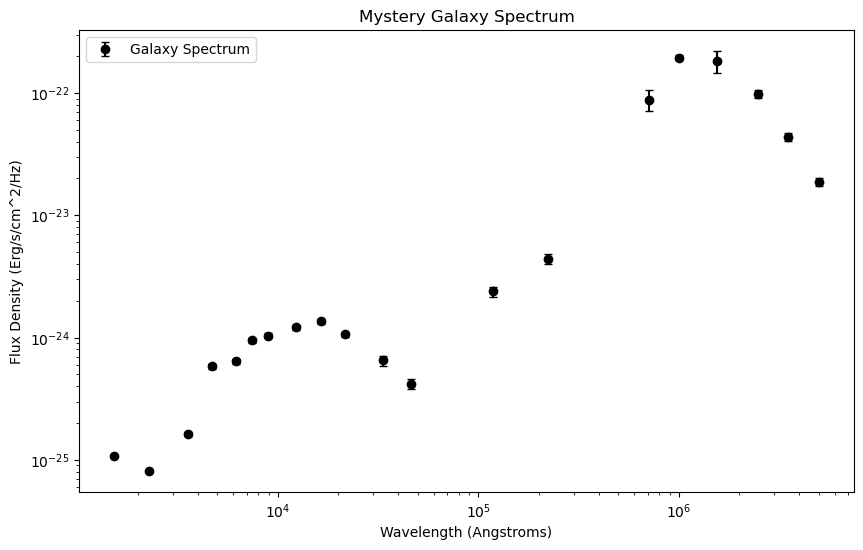

In [25]:
# Plot the galaxy flux density as a function of wavelength
plt.figure(figsize=(10, 6))
plt.errorbar(galaxy_data["Wavelength (Angstrom)"], galaxy_data["Flux Density (erg)"], yerr=[galaxy_data["FD Unc Low (erg)"], galaxy_data["FD Unc High (erg)"]], label="Galaxy Spectrum", fmt="o", capsize=3, ecolor='black', color='black')

# Labels
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux Density (Erg/s/cm^2/Hz)")
plt.title("Mystery Galaxy Spectrum")
plt.legend()

# Scale axes logarithmically
plt.xscale('log')
plt.yscale('log')

# Show plot
plt.show()

In [ ]:
# Function to plot the underlying data
# Returns the fig, ax objects so we can plot on top of it
def plot_data():
    # Plot the galaxy flux density as a function of wavelength
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(galaxy_data["Wavelength (Angstrom)"], galaxy_data["Flux Density (erg)"], yerr=[galaxy_data["FD Unc Low (erg)"], galaxy_data["FD Unc High (erg)"]], label="Galaxy Spectrum", fmt="o", capsize=3, ecolor='black', color='black')

    # Labels
    ax.set_xlabel("Wavelength (Angstroms)")
    ax.set_ylabel("Flux Density (Erg/s/cm^2/Hz)")
    ax.set_title("Mystery Galaxy Spectrum")

    # Scale axes logarithmically
    ax.set_xscale('log')
    ax.set_yscale('log')

    return fig, ax


# Make a function to plot a model underneath the data
# Model is a list of tuples of (wavelengths, flux densities in angstrom and erg/s/cm^2/Hz)
# Label is a string to label the model in the legend
def plot_model(models, labels=None): 
    # Check inputs
    if type(models) is not list and type(models) is not type(np.array([1])):
        models = [models]
        print(f"type models wrong: {type(models)}")
    if type(labels) is not list and type(np.array([1])):
        labels = [labels]
        print(f"Type labels wrong: {type(labels)}")
    assert(len(models) == len(labels)), "Labels must be the same length as models"

    # Plot the measured data
    fig, ax = plot_data()

    # Plot model(s)
    for i, model in enumerate(models):
        wavelengths, flux_densities = model 
        label = labels[i]
        ax.plot(wavelengths, flux_densities, label=label)
    
    plt.legend()
    return fig, ax


In [ ]:
# sp = fsps.StellarPopulation(zcontinuous=1, logzsol=0.0, 
#                             sfh=4, tau=1.0, 
#                             dust_type=2,
#                             add_neb_emission=True, 
#                             add_dust_emission=True)

# # dust_depths = [0.0, 0.5, 2.0, 5.0, 10.0]
# dust_depths = [0.0, 2.0, 5.0]
# age = 5.0

# # Store results in a dictionary: {dust_value: spectrum_array}
# sed_data = {}
# wave, _ = sp.get_spectrum(tage=age, peraa=True) # Get wavelength grid once

# for d in dust_depths:
#     sp.params['dust2'] = d
#     _, spec = sp.get_spectrum(tage=age, peraa=True)
#     sed_data[d] = spec.copy() # Store a copy of the spectrum